In [63]:
df.sort_values(by="logp", ascending=False)[80000:80010]

,param_0,param_1,logp
147609,8.331818,0.694556,-1583.383093
147220,8.332504,0.697832,-1583.383103
277360,8.331797,0.694066,-1583.383162
277460,8.331797,0.694066,-1583.383162
224094,8.331852,0.695458,-1583.383166
224194,8.331852,0.695458,-1583.383166
173956,8.332025,0.697529,-1583.383197
202813,8.332104,0.698512,-1583.383211
202713,8.332104,0.698512,-1583.383211
219250,8.332325,0.697499,-1583.383221


In [1]:
import pandas as pd

# Read the chain file
a = pd.read_csv('chain.txt', sep=' ', header=None, comment='#')

# Round both columns to 2 decimal places
a_rounded = a.round(2)

# Count how many times each (Av, logAge) pair appears
counts = a_rounded.value_counts()

# Get the most frequent combination
most_common = counts.idxmax()
freq = counts.max()

print(f"Most frequent combination (rounded to 2 decimals): {most_common}")
print(f"Frequency: {freq} occurrences")

# If you want to see the top few:
print("\nTop 5 most common combinations:")
print(counts.head())


Most frequent combination (rounded to 2 decimals): (8.38, 0.67, -1836.99)
Frequency: 4853 occurrences

Top 5 most common combinations:
0     1     2       
8.38  0.67  -1836.99    4853
8.39  0.66  -1837.88    4814
8.42  0.63  -1882.75    4745
8.39  0.64  -1842.36    4723
8.32  0.69  -1790.42    4692
Name: count, dtype: int64


In [2]:
a

,0,1,2
0,8.771012,1.031433,-37136.131136
1,8.536179,0.781389,-9802.356359
2,8.579562,1.030468,-22902.427919
3,8.462385,0.490570,-3036.430258
4,8.588167,0.005890,-10648.228145
...,...,...,...
499995,8.409470,0.636556,-1814.391033
499996,8.315228,0.731229,-1856.879543
499997,8.408364,0.652699,-1853.646363
499998,8.326930,0.650439,-1763.598730


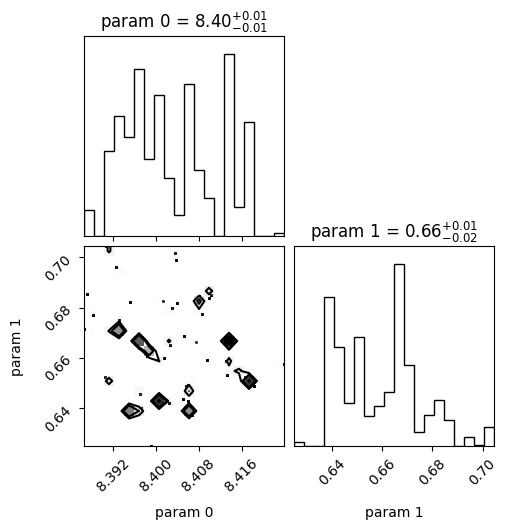

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import corner

# burn-in fraction
burn_in_frac = 0.2
burn_in = int(len(a) * burn_in_frac)

# discard burn-in, then thin
thin = 10
a_burned = a.iloc[burn_in:, :].reset_index(drop=True)
a_thinned = a_burned.iloc[::thin, :].reset_index(drop=True)

# drop likelihood column (assuming it's the 3rd column, index 2)
params_only =  a_thinned.drop(a_thinned.columns[2], axis=1)

# corner plot
figure = corner.corner(
    params_only.values,
    labels=[f"param {i}" for i in range(params_only.shape[1])],
    show_titles=True
)
plt.show()

Columns: ['Zini', 'MH', 'logAge', 'Mini', 'int_IMF', 'Mass', 'logL', 'logTe', 'logg', 'label', 'McoreTP', 'C_O', 'period0', 'period1', 'period2', 'period3', 'period4', 'pmode', 'Mloss', 'tau1m', 'X', 'Y', 'Xc', 'Xn', 'Xo', 'Cexcess', 'Z', 'mbolmag', 'Umag', 'Bmag', 'Vmag', 'Rmag', 'Imag', 'Jmag', 'Hmag', 'Kmag', 'U-B', 'B-V', 'V-I']


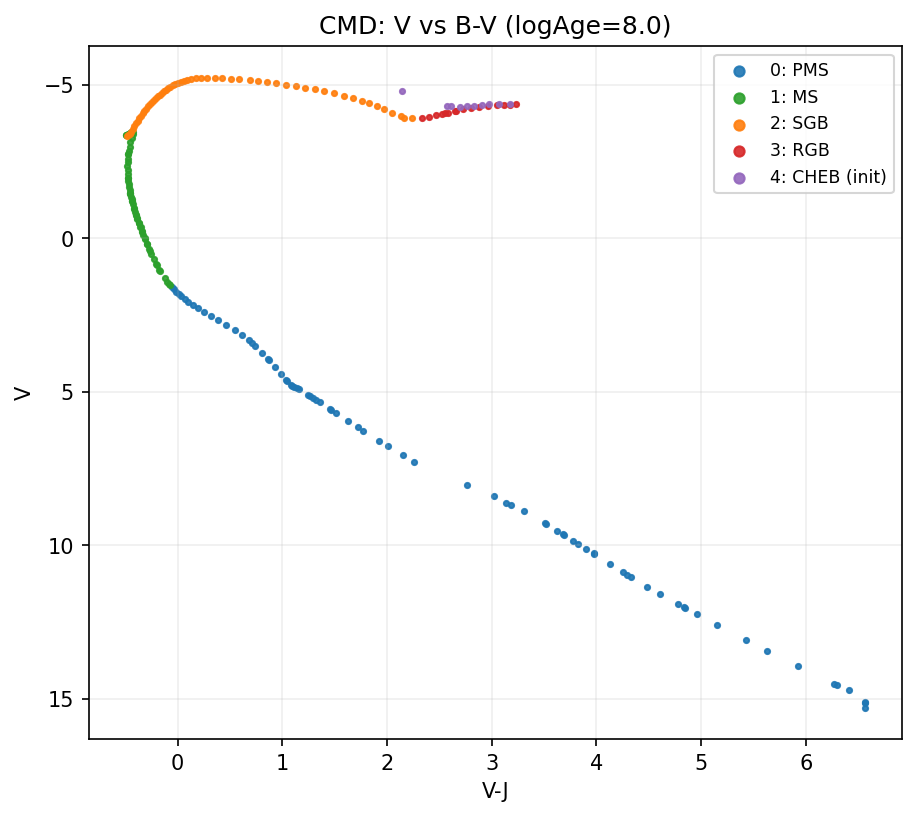

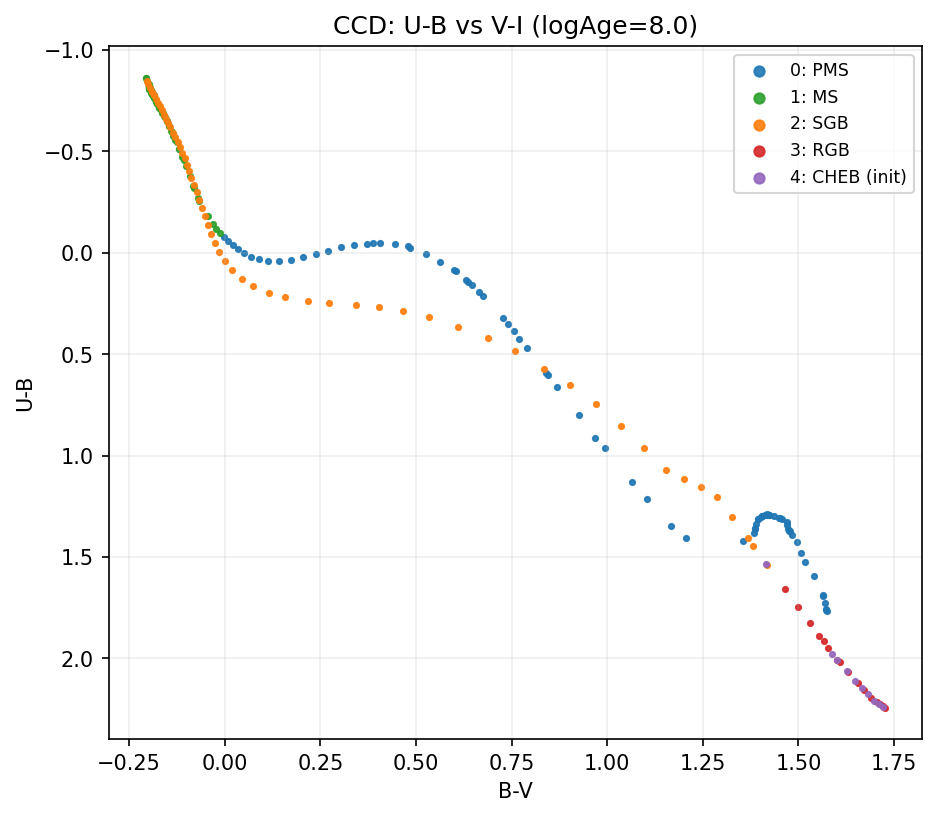

In [4]:
import os
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PATH = "/home/sandro/PycharmProjects/ASteCA/Isochrones/isocronas_UBVRI_idades_6.5-10.dat"

# stage labels and colours (from your list)
stage_labels = {
    0: "PMS",
    1: "MS",
    2: "SGB",
    3: "RGB",
    4: "CHEB (init)",
    5: "CHEB (bluward)",
    6: "CHEB (redward)",
    7: "EAGB",
    8: "TPAGB",
    9: "post-AGB"
}

stage_colors = {
    0: "#1f77b4",
    1: "#2ca02c",
    2: "#ff7f0e",
    3: "#d62728",
    4: "#9467bd",
    5: "#8c564b",
    6: "#e377c2",
    7: "#7f7f7f",
    8: "#bcbd22",
    9: "#17becf",
}

def load_padova_isochrone(path):
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # find the header line starting with "#Zini"
    header_line = None
    for i, line in enumerate(lines):
        if line.lstrip().startswith("#Zini"):
            header_line = line
            break

    if header_line is None:
        raise ValueError("Could not find header line starting with '#Zini' in file.")

    # build column names from the header line (strip leading '#' and split on whitespace)
    colnames = header_line.lstrip('#').strip().split()
    # Extract only data lines (those not starting with '#')
    data_lines = [ln for ln in lines if not ln.lstrip().startswith('#') and ln.strip() != '']
    data_str = "".join(data_lines)
    df = pd.read_csv(StringIO(data_str), delim_whitespace=True, names=colnames, header=None, engine='python')

    # convert numeric columns to numeric where possible
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    return df

def compute_expression(df, expr):
    """
    Compute expression like "B-V" or "V-I" or "U-B".
    expr is a string of form "<mag1>-<mag2>" (no spaces required).
    Returns a pandas Series of floats (NaN where not computable).
    """
    expr = expr.replace(" ", "")
    if "-" not in expr:
        raise ValueError("Expression must be of form 'A-B' (e.g. 'B-V').")
    a, b = expr.split("-", 1)
    # Accept either e.g. "B" meaning "Bmag" or full column names "Bmag"
    def pick_col(token):
        # direct match
        if token in df.columns:
            return token
        # try appended "mag"
        cand = token + "mag"
        if cand in df.columns:
            return cand
        # try uppercase forms (in case)
        cand2 = token.upper() + "mag"
        if cand2 in df.columns:
            return cand2
        # fallback: try to find column startswith token
        for c in df.columns:
            if c.lower().startswith(token.lower()):
                return c
        raise KeyError(f"Could not find a magnitude column for token '{token}' in dataframe columns.")
    col_a = pick_col(a)
    col_b = pick_col(b)
    return df[col_a] - df[col_b]

def plot_isochrone(df, x_expr="V-I", y_expr="V", stage_col='label',
                   colors=stage_colors, labels=stage_labels,
                   age=None, figsize=(7,6), s=6, alpha=0.9,
                   invert_y=False, title=None, savepath=None):
    """
    Generic plotter:
    - x_expr: string like "V-I" or "B-V" (must be of form A-B)
    - y_expr: either a magnitude column ("Vmag","V") or an expression "U-B"
    - age: if provided (e.g. 8.0) filter df by df.logAge == age
    - invert_y: whether to invert y-axis (typical for magnitudes)
    """
    df_plot = df.copy()
    if age is not None:
        df_plot = df_plot[df_plot['logAge'] == age]

    # compute x and y series
    # if y_expr contains "-" treat as colour expression, else single mag
    try:
        x = compute_expression(df_plot, x_expr)
    except Exception as e:
        raise RuntimeError(f"Failed to compute x expression '{x_expr}': {e}")

    if "-" in str(y_expr):
        y = compute_expression(df_plot, y_expr)
        invert_y_local = False  # colour-colour usually not inverted
    else:
        # y is a single magnitude column
        token = str(y_expr)
        # try direct names or with 'mag' suffix
        if token in df_plot.columns:
            y = df_plot[token]
        elif token + 'mag' in df_plot.columns:
            y = df_plot[token + 'mag']
        else:
            # try upper-case + mag
            token2 = token.upper() + 'mag'
            if token2 in df_plot.columns:
                y = df_plot[token2]
            else:
                raise KeyError(f"Could not find magnitude column for y_expr '{y_expr}'")
        invert_y_local = True if invert_y else False

    # stage column handling
    if stage_col not in df_plot.columns:
        print(f"Warning: stage column '{stage_col}' not found. Plotting all points in grey.")
        stage_col = None

    # build figure
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    if invert_y_local:
        ax.invert_yaxis()
    ax.set_xlabel(x_expr.replace("mag", ""))
    ax.set_ylabel(y_expr.replace("mag", ""))

    # plotting
    if stage_col is None:
        mask = (~x.isna()) & (~y.isna())
        ax.scatter(x[mask], y[mask], s=s, alpha=alpha, color='0.6', label='isochrone')
    else:
        stages_present = np.unique(df_plot[stage_col].dropna().astype(int))[:5]
        for st in sorted(stages_present):
            st_mask = (~x.isna()) & (~y.isna()) & (df_plot[stage_col].fillna(-1).astype(int) == int(st))
            if np.count_nonzero(st_mask) == 0:
                continue
            col = colors.get(int(st), '#000000')
            lab = labels.get(int(st), f"stage {st}")
            ax.scatter(x[st_mask], y[st_mask], s=s, alpha=alpha, color=col, label=f"{int(st)}: {lab}")

    ax.invert_yaxis()
    ax.legend(markerscale=2, fontsize='small', loc='best')
    ax.grid(alpha=0.2)
    if title:
        ax.set_title(title)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

# usage example
if __name__ == "__main__":
    df_iso = load_padova_isochrone(PATH)
    print("Columns:", df_iso.columns.tolist())

    # Example 1: original CMD B-V vs V (magnitude inverted)
    plot_isochrone(df_iso, x_expr="V-J", y_expr="V", stage_col='label',
                   age=7.5, title="CMD: V vs B-V (logAge=8.0)")

    # Example 2: CCD U-B (y) vs V-I (x) as you requested (do NOT invert y)
    # Here we set invert_y=False because colour-colour diagrams are not magnitude axes.
    plot_isochrone(df_iso, x_expr="B-V", y_expr="U-B", stage_col='label',
                   age=7.5, invert_y=False, title="CCD: U-B vs V-I (logAge=8.0)")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
a = pd.read_csv('dias_dr3_0.5.csv')

In [ ]:
a = a[a.cluster == 'Blanco_1']

In [ ]:
a=a[~a.Vmag.isna()]

In [ ]:
a

In [ ]:
import psutil
psutil.cpu_count(logical=True)

In [ ]:
# hogg_emcee_mixture.py
# Requirements:
# pip install numpy scipy matplotlib pandas emcee corner statsmodels
# statsmodels only needed for the optional lower-envelope initialization helper.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import interp1d
from scipy.optimize import minimize
import emcee
import pandas as pd
import time
import sys

# Optional: corner for posterior corner plot
try:
    import corner
    _HAS_CORNER = True
except Exception:
    _HAS_CORNER = False

# ----------------------
# Helper: find error column names in DataFrame a
def find_error_columns(a):
    eX_candidates = ['e_Vmag-Imag', 'e_Vmag_Imag', 'e_VmagImag', 'e_VmagMinusImag', 'e_V-I']
    eY_candidates = ['e_Vmag', 'e_Vmag_err', 'Vmag_err', 'e_V']
    eX_name = next((c for c in eX_candidates if c in a.columns), None)
    eY_name = next((c for c in eY_candidates if c in a.columns), None)
    return eX_name, eY_name

# ----------------------
# Helper: estimate initial polynomial coefficients by fitting a local lower-envelope
def initial_poly_from_lower_envelope(x, y, deg=6, frac=0.08, quantile=0.05, ngrid=300):
    """
    Quick lower-envelope estimator: compute local quantile in sliding windows and fit a polynomial to it.
    Returns polynomial coefficients (highest->lowest) for np.polyval.
    """
    order = np.argsort(x)
    xs = x[order]
    ys = y[order]
    n = len(xs)
    window = max(10, int(frac * n))
    # choose grid across x-range and compute local quantiles
    x_grid = np.linspace(xs.min(), xs.max(), ngrid)
    q_vals = np.zeros_like(x_grid)
    idxs = np.searchsorted(xs, x_grid)
    halfw = window // 2
    for i, idx in enumerate(idxs):
        i0 = max(0, idx - halfw)
        i1 = min(n, idx + halfw)
        if i1 - i0 < 5:
            i0 = max(0, idx - window)
            i1 = min(n, idx + window)
        seg = ys[i0:i1]
        if seg.size:
            q_vals[i] = np.quantile(seg, quantile)
        else:
            q_vals[i] = np.nan
    mask = np.isfinite(q_vals)
    if mask.sum() < deg+1:
        # fallback to global polyfit
        coeffs = np.polyfit(x, y, deg)
        return coeffs
    # fit polynomial to (x_grid[mask], q_vals[mask])
    coeffs = np.polyfit(x_grid[mask], q_vals[mask], deg)
    return coeffs

# ----------------------
# The model: polynomial P(x) and derivative dP/dx
def poly_eval_and_deriv(coeffs, x):
    # coeffs highest->lowest
    y = np.polyval(coeffs, x)
    dcoeffs = np.polyder(coeffs)
    dy_dx = np.polyval(dcoeffs, x)
    return y, dy_dx

# ----------------------
# Log-prior following eqs (10)-(13)
def log_prior(theta, p):
    """
    theta vector layout:
      coeffs: p+1 entries (poly, highest->lowest)
      log10_sigma_SS
      log10_sigma_BS
      deltaG
      logit_fb   (we parameterize fb via logit)
    """
    # unpack
    coeffs = theta[:p+1]
    log10_sig_ss = theta[p+1]
    log10_sig_bs = theta[p+2]
    deltaG = theta[p+3]
    logit_fb = theta[p+4]

    # priors:
    # coeffs: flat (improper) -> constant -> return 0 contribution
    lp = 0.0

    # p1: DeltaG ~ Normal(-0.75, 0.05)
    lp += -0.5 * ((deltaG + 0.75) / 0.05)**2 - np.log(0.05 * np.sqrt(2*np.pi))

    # p2: log10 sigma_BS ~ N(-1, 0.2)
    lp += -0.5 * ((log10_sig_bs + 1.0) / 0.2)**2 - np.log(0.2 * np.sqrt(2*np.pi))

    # p3: log10 sigma_SS ~ N(-0.8, 0.2)
    lp += -0.5 * ((log10_sig_ss + 0.8) / 0.2)**2 - np.log(0.2 * np.sqrt(2*np.pi))

    # prior on fb: uniform(0,1) -> we parameterize via logit, Jacobian should be included:
    # If u = logit(fb), fb = 1/(1+exp(-u)). Prior uniform on fb => prior on u is fb'(u) = exp(-u)/(1+exp(-u))^2
    # log prior contribution = log( derivative ) = -u - 2*log(1+exp(-u))
    u = logit_fb
    # But better to ensure proper normalization: using the jacobian is enough (improper otherwise)
    # If we want exactly uniform prior on fb, include jacobian:
    lp += -u - 2.0 * np.log1p(np.exp(-u))

    # return log prior
    return lp

# ----------------------
# Log-likelihood implementing eq. (8) and (9)
def log_likelihood(theta, x, y, sigma_G, sigma_color, p):
    """
    theta layout same as in log_prior.
    sigma_G = measurement error on magnitude (y)
    sigma_color = measurement error on color (x)
    """
    coeffs = theta[:p+1]
    log10_sig_ss = theta[p+1]
    log10_sig_bs = theta[p+2]
    deltaG = theta[p+3]
    logit_fb = theta[p+4]

    fb = 1.0 / (1.0 + np.exp(-logit_fb))
    f_ss = 1.0 - fb
    sigma_SS = 10.0**(log10_sig_ss)
    sigma_BS = 10.0**(log10_sig_bs)

    # evaluate P(x) and derivative
    mu_ss, dPdx = poly_eval_and_deriv(coeffs, x)
    mu_bs = mu_ss + deltaG

    # m_i = (dP/dx)^2
    m_i = dPdx**2

    # sigma_eff^2 = 1/(1 + m_i) * ( sigma_G^2 + m_i * sigma_color^2 )
    sigma_eff2 = (sigma_G**2 + m_i * sigma_color**2) / (1.0 + m_i)

    var_ss = sigma_eff2 + sigma_SS**2
    var_bs = sigma_eff2 + sigma_BS**2

    # component likelihoods
    # To avoid underflow, compute log-sum-exp style per star:
    # p_total = (1-fb) * N(y|mu_ss, var_ss) + fb * N(y|mu_bs, var_bs)
    # compute log p_ss and log p_bs
    # log N(y|mu,var) = -0.5*( (y-mu)^2/var + ln(2π var) )
    ln_p_ss = -0.5 * ( (y - mu_ss)**2 / var_ss + np.log(2*np.pi*var_ss) ) + np.log(f_ss + 1e-300)
    ln_p_bs = -0.5 * ( (y - mu_bs)**2 / var_bs + np.log(2*np.pi*var_bs) ) + np.log(fb + 1e-300)

    # log-sum-exp per star
    ln_max = np.maximum(ln_p_ss, ln_p_bs)
    ln_sum = ln_max + np.log(np.exp(ln_p_ss - ln_max) + np.exp(ln_p_bs - ln_max) + 1e-300)
    return np.sum(ln_sum)

# ----------------------
# Full log-posterior
def log_posterior(theta, x, y, sigma_G, sigma_color, p):
    lp = log_prior(theta, p)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, x, y, sigma_G, sigma_color, p)
    return lp + ll

# ----------------------
# Driver: run emcee and return samples
def run_mcmc(x, y, sigma_G, sigma_color, p=6,
             n_walkers=32, n_steps=10000, burnin=5000, threads=1,
             init_coeffs=None, random_seed=42):
    np.random.seed(random_seed)
    Npars = (p+1) + 4  # coeffs + log10_sig_ss + log10_sig_bs + deltaG + logit_fb

    # Initial guess:
    if init_coeffs is None:
        init_coeffs = initial_poly_from_lower_envelope(x, y, deg=p, frac=0.08, quantile=0.05, ngrid=300)

    # Reasonable central initial values:
    log10_sig_ss0 = -0.8   # prior mean
    log10_sig_bs0 = -1.0   # prior mean
    deltaG0 = -0.75257499
    fb0 = 0.2
    logit_fb0 = np.log(fb0 / (1 - fb0))

    theta0 = np.concatenate([init_coeffs, [log10_sig_ss0, log10_sig_bs0, deltaG0, logit_fb0]])

    # initialize walkers in small ball around theta0
    p0 = np.array([theta0 + 1e-3 * np.random.randn(Npars) for _ in range(n_walkers)])

    # Setup sampler
    sampler = emcee.EnsembleSampler(n_walkers, Npars,
                                    log_posterior,
                                    args=(x, y, sigma_G, sigma_color, p),
                                    threads=threads)

    print(f"Running MCMC: n_walkers={n_walkers}, n_steps={n_steps} (burnin={burnin}) ...")
    t0 = time.time()
    # run burn-in first
    p0, _, _ = sampler.run_mcmc(p0, burnin, progress=True)
    sampler.reset()
    # main run
    sampler.run_mcmc(p0, n_steps, progress=True)
    t1 = time.time()
    print(f"... MCMC finished in {t1 - t0:.1f} s")

    samples = sampler.get_chain(flat=False)  # shape (nwalkers, nsteps, npars)
    flat_samples = sampler.get_chain(discard=0, flat=True)  # flatten after reset so includes all main-run samples

    return sampler, flat_samples

# ----------------------
# Summarize posterior and compute per-star P(binary) using median params
def summarize_and_compute_probs(flat_samples, x, y, sigma_G, sigma_color, p):
    # median and 16/84 percentiles
    med = np.median(flat_samples, axis=0)
    q16 = np.percentile(flat_samples, 16, axis=0)
    q84 = np.percentile(flat_samples, 84, axis=0)

    coeffs_med = med[:p+1]
    log10_sig_ss_med = med[p+1]
    log10_sig_bs_med = med[p+2]
    deltaG_med = med[p+3]
    logit_fb_med = med[p+4]

    fb_med = 1.0 / (1.0 + np.exp(-logit_fb_med))
    sigma_SS_med = 10.0**(log10_sig_ss_med)
    sigma_BS_med = 10.0**(log10_sig_bs_med)

    # compute per-star posterior probabilities using median params
    mu_ss, dPdx = poly_eval_and_deriv(coeffs_med, x)
    mu_bs = mu_ss + deltaG_med
    m_i = dPdx**2
    sigma_eff2 = (sigma_G**2 + m_i * sigma_color**2) / (1.0 + m_i)
    var_ss = sigma_eff2 + sigma_SS_med**2
    var_bs = sigma_eff2 + sigma_BS_med**2

    p_ss = (1.0 - fb_med) * norm.pdf(y, loc=mu_ss, scale=np.sqrt(var_ss))
    p_bs = fb_med * norm.pdf(y, loc=mu_bs, scale=np.sqrt(var_bs))
    denom = p_ss + p_bs + 1e-300
    prob_binary = p_bs / denom
    prob_single = p_ss / denom

    summary = {
        'coeffs_med': coeffs_med,
        'log10_sig_ss_med': log10_sig_ss_med,
        'log10_sig_bs_med': log10_sig_bs_med,
        'deltaG_med': deltaG_med,
        'fb_med': fb_med,
        'sigma_SS_med': sigma_SS_med,
        'sigma_BS_med': sigma_BS_med,
        'p_binary': prob_binary,
        'p_single': prob_single,
        'med_vector': med,
        'q16': q16,
        'q84': q84
    }
    return summary

# ----------------------
# Selection cuts per your list
def selection_cuts(summary, flat_samples):
    # compute sigma_fb as mean of fb's 16th and 84th percentiles
    fb_samples = 1.0 / (1.0 + np.exp(-flat_samples[:, (len(summary['coeffs_med']) + 3)])) \
        if False else None
    # above is messy; simpler compute fb percentiles from flat_samples directly:
    # flat_samples columns: coeffs (p+1), log10_sig_ss, log10_sig_bs, deltaG, logit_fb
    cols = flat_samples.shape[1]
    logit_fb_idx = cols - 1
    logit_fb_vals = flat_samples[:, logit_fb_idx]
    fb_vals = 1.0 / (1.0 + np.exp(-logit_fb_vals))
    fb_p16, fb_p84 = np.percentile(fb_vals, [16, 84])
    sigma_fb = 0.5 * (fb_p84 - fb_p16)  # or mean of 16th and 84th? original text: mean of fb's 16th and 84th percentiles
    sigma_fb_mean = 0.5 * (fb_p16 + fb_p84)  # interpret as mean of the two percentiles

    # get sigma medians and deltaG
    sigma_SS_med = summary['sigma_SS_med']
    sigma_BS_med = summary['sigma_BS_med']
    deltaG_med = summary['deltaG_med']
    fb_med = summary['fb_med']

    cuts = {
        'sigma_SS_ok': (sigma_SS_med <= 0.2),
        'sigma_BS_ok': (sigma_BS_med <= 0.25),
        'deltaG_ok': (np.abs(deltaG_med + 0.75) <= 0.05),
        'sigma_fb_ok': (sigma_fb_mean <= 0.25),
        'sigma_fb_mean': sigma_fb_mean,
        'sigma_fb_width': sigma_fb
    }
    cuts['all_ok'] = all([cuts['sigma_SS_ok'], cuts['sigma_BS_ok'], cuts['deltaG_ok'], cuts['sigma_fb_ok']])
    return cuts

# ----------------------
# Plotting helpers
def diagnostic_plots(x, y, sigma_G, sigma_color, summary, flat_samples, save_prefix=None):
    coeffs_med = summary['coeffs_med']
    deltaG_med = summary['deltaG_med']
    p_binary = summary['p_binary']
    sigma_SS = summary['sigma_SS_med']
    sigma_BS = summary['sigma_BS_med']

    # CMD colored by p_binary
    fig1, ax1 = plt.subplots(figsize=(7,9))
    sc = ax1.scatter(x, y, c=p_binary, cmap='viridis', s=25, edgecolor='none')
    plt.colorbar(sc, ax=ax1, label='P(binary; q>qlim)')
    xgrid = np.linspace(np.nanmin(x), np.nanmax(x), 600)
    y_ss = np.polyval(coeffs_med, xgrid)
    y_bs = y_ss + deltaG_med
    ax1.plot(xgrid, y_ss, color='k', lw=2, label='P(x) (median)')
    ax1.plot(xgrid, y_bs, color='orange', lw=2, ls='--', label=f'P(x)+ΔG, ΔG={deltaG_med:.3f}')
    ax1.invert_yaxis()
    ax1.set_xlabel('Vmag - Imag'); ax1.set_ylabel('Vmag')
    ax1.legend(loc='lower left')
    plt.tight_layout()
    if save_prefix:
        fig1.savefig(save_prefix + '_cmd_prob.png', dpi=180)

    # residual histogram with component curves (use median params)
    resid = y - np.polyval(coeffs_med, x)
    fig2, ax2 = plt.subplots(1,1, figsize=(6,4))
    ax2.hist(resid, bins=60, density=True, alpha=0.5, color='gray', label='residuals')
    avg_yerr = np.mean(sigma_G)
    xs = np.linspace(np.min(resid), np.max(resid), 400)
    comp_ss = (1.0 - summary['fb_med']) * norm.pdf(xs, loc=0.0, scale=np.sqrt(sigma_SS**2 + avg_yerr**2))
    comp_bs = summary['fb_med'] * norm.pdf(xs, loc=deltaG_med, scale=np.sqrt(sigma_BS**2 + avg_yerr**2))
    ax2.plot(xs, comp_ss, lw=1.6, color='k', label='SS comp')
    ax2.plot(xs, comp_bs, lw=1.6, color='orange', label='BS comp')
    ax2.plot(xs, comp_ss + comp_bs, lw=1.2, color='k', ls='--', label='total')
    ax2.set_xlabel('G - P(x)')
    ax2.legend()
    plt.tight_layout()
    if save_prefix:
        fig2.savefig(save_prefix + '_resid_hist.png', dpi=150)

    # optional corner plot for a subset of parameters
    if _HAS_CORNER:
        # pick columns: log10_sig_ss, log10_sig_bs, deltaG, fb
        p_all = flat_samples.shape[1]
        # find indices for the last 4 parameters
        inds = [p_all-4, p_all-3, p_all-2, p_all-1]  # careful: depends on layout
        labels = ['log10_sig_ss', 'log10_sig_bs', 'deltaG', 'fb']
        # but need to convert logit_fb to fb for corner: transform
        corner_samples = np.zeros((flat_samples.shape[0], 4))
        corner_samples[:,0] = flat_samples[:, p]  # log10_sig_ss
        corner_samples[:,1] = flat_samples[:, p+1]  # log10_sig_bs (note shift if p changed)
        corner_samples[:,2] = flat_samples[:, p+2]  # deltaG
        logit_fb_vals = flat_samples[:, p+3]
        corner_samples[:,3] = 1.0 / (1.0 + np.exp(-logit_fb_vals))
        figc = corner.corner(corner_samples, labels=labels, truths=[summary['log10_sig_ss_med'], summary['log10_sig_bs_med'], summary['deltaG_med'], summary['fb_med']])
        if save_prefix:
            figc.savefig(save_prefix + '_corner.png', dpi=150)

    plt.show()

# ----------------------
# MAIN: use your DataFrame `a` and run the whole chain
if __name__ == "__main__":
    # assume `a` pandas DataFrame exists in environment
    if 'a' not in globals() and 'a' not in locals():
        raise RuntimeError("DataFrame `a` not found. Load your data as a pandas DataFrame named `a` before running.")

    # Prepare arrays
    x = a['Vmag-Imag'].values
    y = a['Vmag'].values

    eX_name, eY_name = find_error_columns(a)
    if eY_name is None:
        raise RuntimeError("Could not find magnitude error column. Add a column like 'e_Vmag' in your DataFrame `a`.")
    if eX_name is None:
        print("Warning: color-error column not found. We will set color errors to a small constant (1e-3).")
        sigma_color = np.full_like(x, 1e-3)
    else:
        sigma_color = a[eX_name].values

    sigma_G = a[eY_name].values

    # MCMC configuration (match your quoted setup if desired)
    p = 6  # polynomial degree; the paper used p=6
    n_walkers = 32
    n_steps = 10000
    burnin = 5000
    threads = 1  # set >1 if you want parallelization

    # initial polynomial from lower envelope for robust starting point
    init_coeffs = initial_poly_from_lower_envelope(x, y, deg=p, frac=0.08, quantile=0.05, ngrid=400)

    # Run MCMC
    sampler, flat_samples = run_mcmc(x, y, sigma_G, sigma_color, p=p,
                                    n_walkers=n_walkers, n_steps=n_steps,
                                    burnin=burnin, threads=threads,
                                    init_coeffs=init_coeffs, random_seed=123)

    # Summarize and compute p_binary (using median parameter vector)
    summary = summarize_and_compute_probs(flat_samples, x, y, sigma_G, sigma_color, p)
    print("\nPosterior medians (and approximate):")
    print(f"  f_b (q>qlim) med = {summary['fb_med']:.4f}")
    print(f"  sigma_SS med = {summary['sigma_SS_med']:.4f}")
    print(f"  sigma_BS med = {summary['sigma_BS_med']:.4f}")
    print(f"  deltaG med = {summary['deltaG_med']:.4f}")
    print("  polynomial coeffs (highest->lowest):")
    print(summary['coeffs_med'])

    # attach p_binary to DataFrame 'a'
    a['p_binary_qgtqlim'] = summary['p_binary']

    # Selection cuts
    cuts = selection_cuts(summary, flat_samples)
    print("\nSelection cuts summary:")
    for k,v in cuts.items():
        print(f"  {k}: {v}")
    if cuts['all_ok']:
        print("\nThis cluster passes the selection cuts (σSS ≤ 0.2, σBS ≤ 0.25, |ΔG +0.75| ≤ 0.05, σ_fb ≤ 0.25).")
    else:
        print("\nThis cluster does NOT pass the selection cuts.")

    # Diagnostics plots
    diagnostic_plots(x, y, sigma_G, sigma_color, summary, flat_samples, save_prefix='hogg_mcmc_output')

    # Save posterior samples and summary if desired
    np.save('hogg_flat_samples.npy', flat_samples)
    import json
    with open('hogg_summary.json', 'w') as f:
        json.dump({
            'f_b_med': float(summary['fb_med']),
            'sigma_SS_med': float(summary['sigma_SS_med']),
            'sigma_BS_med': float(summary['sigma_BS_med']),
            'deltaG_med': float(summary['deltaG_med']),
            'coeffs_med': summary['coeffs_med'].tolist()
        }, f, indent=2)

    print("\nSaved flat_samples -> 'hogg_flat_samples.npy' and summary -> 'hogg_summary.json'.")

In [2]:
import numpy as np
import time
from scipy.spatial import KDTree as SciPyKDTree
from sklearn.neighbors import KDTree as SklearnKDTree

# Generate synthetic 2D dataset
N = 10000
Q = 200
K = 5
X = np.random.rand(N, 2)
queries = np.random.rand(Q, 2)

# --- SciPy KDTree ---
start = time.time()
scipy_tree = SciPyKDTree(X)
build_scipy = (time.time() - start) * 1000  # ms

start = time.time()
dists_scipy, idx_scipy = scipy_tree.query(queries, k=K)
query_scipy = (time.time() - start) * 1000  # ms

# --- scikit-learn KDTree ---
start = time.time()
sk_tree = SklearnKDTree(X, leaf_size=40)
build_sk = (time.time() - start) * 1000  # ms

start = time.time()
dists_sk, idx_sk = sk_tree.query(queries, k=K)
query_sk = (time.time() - start) * 1000  # ms

# --- Results ---
print("SciPy KDTree:   build = %.2f ms, query = %.2f ms" % (build_scipy, query_scipy))
print("Sklearn KDTree: build = %.2f ms, query = %.2f ms" % (build_sk, query_sk))



SciPy KDTree:   build = 1.54 ms, query = 0.20 ms
Sklearn KDTree: build = 1.23 ms, query = 0.29 ms


In [3]:
import numpy as np
import time

# --- Synthetic dataset ---
np.random.seed(42)
dim = 128          # vector dimensionality
n_data = 100000    # dataset size
n_query = 1000     # number of queries

data = np.random.random((n_data, dim)).astype('float32')
queries = np.random.random((n_query, dim)).astype('float32')

# --- Benchmark helper ---
def benchmark(name, build_fn, search_fn, k=10):
    print(f"\n{name} benchmark:")
    start = time.time()
    index = build_fn(data)
    build_time = time.time() - start
    print(f"Build time: {build_time:.2f}s")

    start = time.time()
    results = search_fn(index, queries, k)
    search_time = time.time() - start
    print(f"Search time: {search_time:.2f}s")
    return results

# --- HNSWlib ---
import hnswlib
def build_hnsw(data):
    dim = data.shape[1]
    index = hnswlib.Index(space='l2', dim=dim)
    index.init_index(max_elements=data.shape[0], ef_construction=200, M=16)
    index.add_items(data)
    index.set_ef(50)
    return index

def search_hnsw(index, queries, k):
    labels, distances = index.knn_query(queries, k=k)
    return labels

benchmark("HNSWlib", build_hnsw, search_hnsw)

# --- Faiss (CPU only) ---
import faiss
def build_faiss(data):
    dim = data.shape[1]
    index = faiss.IndexFlatL2(dim)  # CPU exact search
    index.add(data)
    return index

def search_faiss(index, queries, k):
    distances, labels = index.search(queries, k)
    return labels

benchmark("Faiss (CPU)", build_faiss, search_faiss)

# --- Annoy ---
from annoy import AnnoyIndex
def build_annoy(data):
    dim = data.shape[1]
    index = AnnoyIndex(dim, 'euclidean')
    for i, v in enumerate(data):
        index.add_item(i, v)
    index.build(10)  # number of trees
    return index

def search_annoy(index, queries, k):
    return [index.get_nns_by_vector(q, k) for q in queries]

benchmark("Annoy", build_annoy, search_annoy)

# --- FLANN ---
from pyflann import FLANN
def build_flann(data):
    flann = FLANN()
    flann.build_index(data, algorithm='kdtree', trees=8)
    return flann

def search_flann(index, queries, k):
    labels, _ = index.nn_index(queries, num_neighbors=k)
    return labels

benchmark("FLANN", build_flann, search_flann)


ModuleNotFoundError: No module named 'hnswlib'

In [4]:
from catalogues import get_catalogue
import os
import pandas as pd

# Load data
df = get_catalogue(['Hunt'])[0]
df = df[(df.r_sun < 1000) & (df.age < 300)]
cluster_names = df['cluster'].unique()


# Merge results
result_files = [
    os.path.join(f"./junk/results_{name}.csv")
    for name in cluster_names
    if os.path.exists(f"./junk/results_{name}.csv")
]

if result_files:
    combined = pd.concat((pd.read_csv(f) for f in result_files), ignore_index=True)
    merged_path = os.path.join(f'/home/sandro/PycharmProjects/ASteCA/Sandro_parsec_UBVRI_cmd_ccd_kde/Dias_parsec_UBVRI_cmd_ccd_kde.csv')
    combined.to_csv(merged_path, index=False)
    print(f"Merged all results into {merged_path}")
else:
    print("No result files were generated.")

Merged all results into /home/sandro/PycharmProjects/ASteCA/Sandro_parsec_UBVRI_cmd_ccd_kde/Dias_parsec_UBVRI_cmd_ccd_kde.csv


In [1]:
from catalogues import get_catalogue
import os
import pandas as pd

# Load data
df = get_catalogue(['Dias'])[0]
df = df[(df.r_sun < 1500) & (df.age < 300)]
cluster_names = df['cluster'].unique()

In [24]:
df[df.cluster == 'COIN-Gaia_21'].age

198    22.803421
Name: age, dtype: float64